## Handwritten character recognition using Deep Learning

Pengenalan karakter tulisan tangan (Handwriting Character Recognition) adalah teknologi yang memungkinkan komputer untuk mengenali dan mengklasifikasikan tulisan tangan manusia. Teknologi ini digunakan dalam berbagai aplikasi, mulai dari pemindaian formulir hingga OCR (Optical Character Recognition). Deep Learning, khususnya melalui penggunaan Convolutional Neural Networks (CNN), telah membawa kemajuan signifikan dalam akurasi pengenalan karakter tulisan tangan.



Konsep Dasar
- Pengenalan karakter tulisan tangan adalah masalah klasifikasi gambar, di mana model dilatih untuk mengenali huruf, angka, atau simbol tertentu yang ditulis secara manual. Tantangan dalam tugas ini meliputi variasi dalam gaya penulisan individu, ketebalan garis, kemiringan, dan bahkan tingkat keterbacaan.

- Deep Learning menawarkan pendekatan yang sangat efisien untuk menyelesaikan masalah ini, dengan menggunakan jaringan saraf tiruan yang mampu belajar dari sejumlah besar data gambar tulisan tangan.



Langkah-langkah Pengenalan Karakter Tulisan Tangan Menggunakan Deep Learning
- Pengumpulan Data: Untuk membangun model yang akurat, diperlukan dataset yang besar berisi contoh karakter tulisan tangan. Salah satu dataset yang paling sering digunakan adalah MNIST Dataset, yang terdiri dari 70.000 gambar tulisan tangan angka (0-9) dalam format 28x28 piksel.

- Preprocessing Gambar: Sebelum gambar tulisan tangan diproses oleh model, dilakukan beberapa langkah preprocessing:

- Normalisasi: Nilai piksel gambar dinormalisasi agar berada dalam rentang 0-1 untuk mempercepat proses pelatihan.
Resizing: Gambar diubah ukurannya agar sesuai dengan ukuran input model.
Binarisasi: Dalam beberapa kasus, gambar diubah menjadi hitam-putih untuk menyederhanakan proses klasifikasi.
Arsitektur Deep Learning (CNN): Model Convolutional Neural Network (CNN) digunakan untuk ekstraksi fitur dari gambar karakter tulisan tangan. CNN terdiri dari beberapa lapisan konvolusi yang bertugas mendeteksi fitur-fitur penting seperti tepi, sudut, dan bentuk huruf atau angka. Beberapa lapisan pooling digunakan untuk mengurangi dimensi gambar tanpa kehilangan informasi penting, dan lapisan fully connected di akhir model bertugas untuk melakukan klasifikasi.

Pelatihan Model:

- Forward Propagation: Model mengambil gambar input dan menghasilkan prediksi probabilitas untuk setiap kelas (misalnya, angka 0-9).
Backpropagation: Berdasarkan kesalahan prediksi (loss), model memperbarui bobotnya melalui algoritma optimisasi (seperti Adam atau SGD) sehingga dapat melakukan prediksi yang lebih baik pada iterasi berikutnya.
Model dilatih pada sejumlah besar gambar hingga mencapai akurasi yang memadai.
Evaluasi: Setelah model selesai dilatih, kinerjanya dievaluasi menggunakan data uji untuk melihat seberapa baik model mengenali karakter tulisan tangan yang belum pernah dilihat sebelumnya.

- Penggunaan Model: Setelah model dilatih dan dievaluasi, model tersebut dapat digunakan untuk mengenali karakter tulisan tangan dari gambar baru yang diinputkan.



## 1. Setup & Imports

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
# Ambil kredensial Kaggle dari Colab Secrets, fallback input manual jika belum ada
import os
from google.colab import userdata
import getpass

try:
    KAGGLE_USERNAME = userdata.get('KAGGLE_USERNAME')
    KAGGLE_KEY = userdata.get('KAGGLE_KEY')
except Exception:
    KAGGLE_USERNAME = None
    KAGGLE_KEY = None

if not KAGGLE_USERNAME or not KAGGLE_KEY:
    print("KAGGLE_USERNAME/KAGGLE_KEY belum ada di Colab Secrets, silakan input manual:")
    KAGGLE_USERNAME = input("KAGGLE_USERNAME: ")
    KAGGLE_KEY = getpass.getpass("KAGGLE_KEY: ")

os.environ['KAGGLE_USERNAME'] = KAGGLE_USERNAME
os.environ['KAGGLE_KEY'] = KAGGLE_KEY

In [4]:
!pip install kagglehub

import kagglehub

# Download dataset ke folder lokal Colab
path = kagglehub.dataset_download("sachinpatel21/az-handwritten-alphabets-in-csv-format")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'az-handwritten-alphabets-in-csv-format' dataset.
Path to dataset files: /kaggle/input/az-handwritten-alphabets-in-csv-format


In [5]:
!ls -lh "{path}"

total 667M
drwxr-sr-x 2 ubuntu ubuntu    0 Sep 16 15:22 'A_Z Handwritten Data'
-rw-r--r-- 1 ubuntu ubuntu 667M Sep 16 15:22 'A_Z Handwritten Data.csv'


https://www.kaggle.com/datasets/sachinpatel21/az-handwritten-alphabets-in-csv-format

## 2. Load Dataset

In [6]:
data = pd.read_csv(path + "/A_Z Handwritten Data.csv").astype("float32")
data.head(10)

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.639,0.640,0.641,0.642,0.643,0.644,0.645,0.646,0.647,0.648
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
X = data.drop('0',axis = 1)
y = data['0']

In [8]:
train_x, test_x, train_y, test_y = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
train_x = np.reshape(train_x.values, (train_x.shape[0], 28, 28))
test_x = np.reshape(test_x.values, (test_x.shape[0], 28, 28))
print(f"Train data shape: {train_x.shape}")
print(f"Test data shape: {test_x.shape}")

Train data shape: (297960, 28, 28)
Test data shape: (74490, 28, 28)


In [9]:
word_dict = {0:'A',1:'B',2:'C',3:'D',4:'E',5:'F',6:'G',7:'H',8:'I',9:'J',
             10:'K',11:'L',12:'M',13:'N',14:'O',15:'P',16:'Q',17:'R',18:'S',
             19:'T',20:'U',21:'V',22:'W',23:'X', 24:'Y',25:'Z'}

## 3. Exploratory Data Analysis

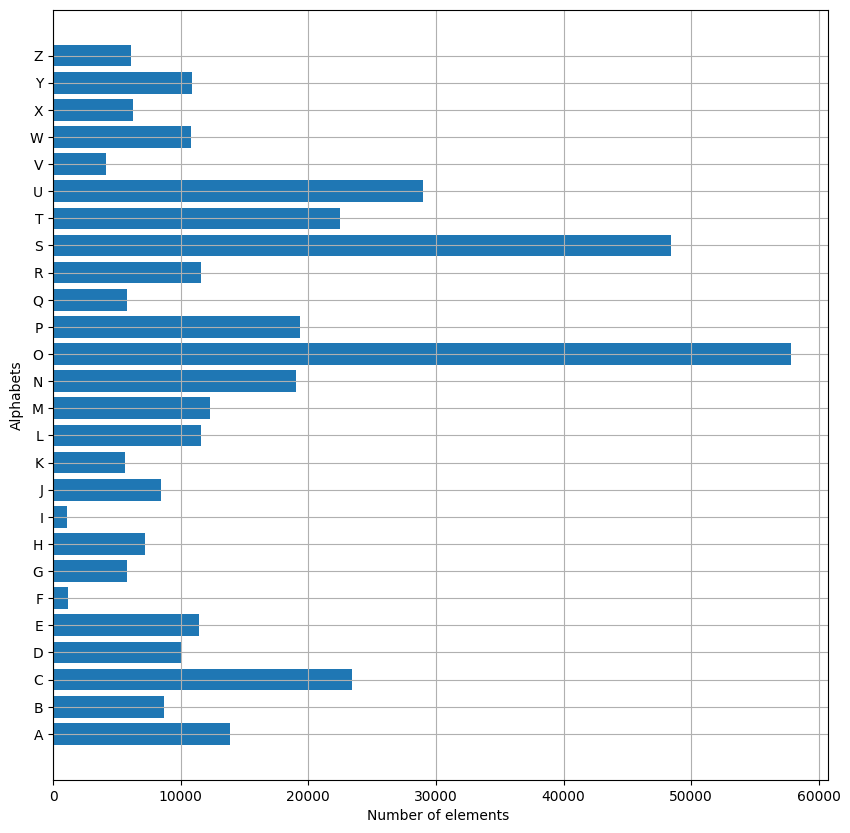

In [10]:
y_int = np.int64(y)
count = np.zeros(26, dtype='int')
for i in y_int:
    count[i] +=1

alphabets = []
for i in word_dict.values():
    alphabets.append(i)

fig, ax = plt.subplots(1,1, figsize=(10,10))
ax.barh(alphabets, count)

plt.xlabel("Number of elements ")
plt.ylabel("Alphabets")
plt.grid()
plt.show()

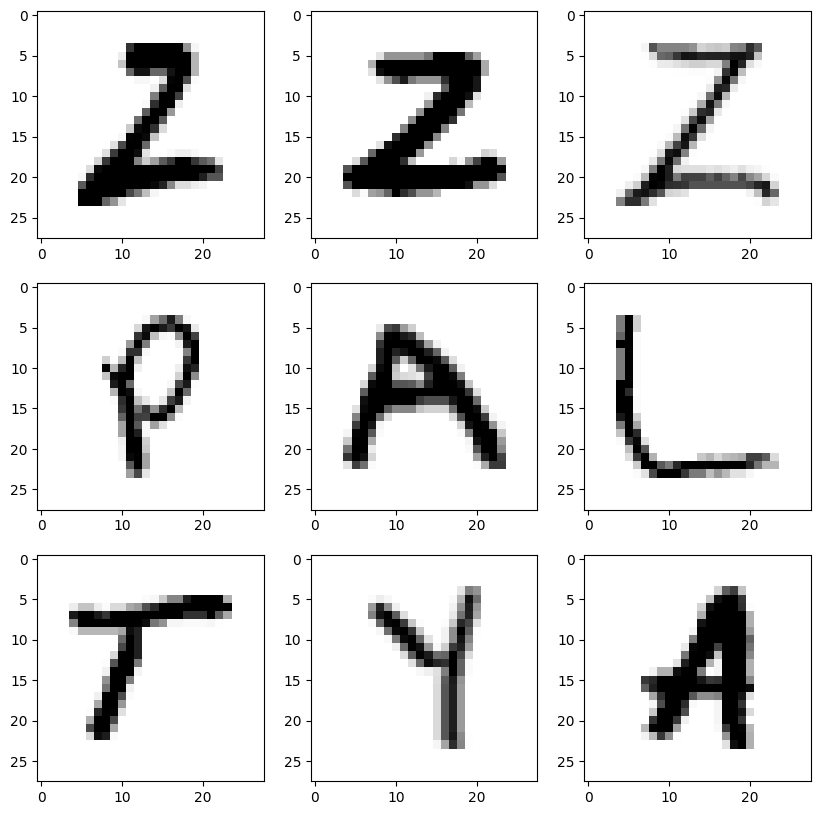

In [11]:
shuff = shuffle(train_x[:100])

fig, ax = plt.subplots(3,3, figsize = (10,10))
axes = ax.flatten()

for i in range(9):
    axes[i].imshow(np.reshape(shuff[i], (28,28)), cmap="Greys")
plt.show()

## 4. Preprocessing

In [ ]:
train_X = train_x.reshape(train_x.shape[0],train_x.shape[1],train_x.shape[2],1)
print(f"New shape of train data: {train_X.shape}")

test_X = test_x.reshape(test_x.shape[0], test_x.shape[1], test_x.shape[2],1)
print(f"New shape of test data: {test_X.shape}")

In [13]:
# Convert to one-hot encoding (OHE)
train_yOHE = to_categorical(train_y, num_classes=26).astype('int')
test_yOHE = to_categorical(test_y, num_classes=26).astype('int')
print(f"New shape of train labels: {train_yOHE.shape}")
print(f"New shape of test labels: {test_yOHE.shape}")

New shape of train labels: (297960, 26)
New shape of test labels: (74490, 26)


## 5. Handling Class Imbalance

Distribusi kelas timpang (lihat chart distribusi di atas — `O`/`S` puluhan ribu sampel, `F`/`I` seribuan). Untuk mengurangi bias model terhadap kelas mayoritas, dihitung `class_weight` per kelas dan diteruskan ke `model.fit()`, supaya kesalahan pada kelas minoritas diberi bobot lebih besar saat training.

In [14]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_y),
    y=train_y
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print("Class weight (min - max):", min(class_weight_dict.values()), "-", max(class_weight_dict.values()))

Class weight (min - max): 0.24773022049286642 - 12.790178571428571


## 6. Model Architecture

In [15]:
model = Sequential()

model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPool2D(pool_size=(2, 2), strides=2))

model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2, 2), strides=2))

model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='valid'))
model.add(MaxPool2D(pool_size=(2, 2), strides=2))

model.add(Flatten())

model.add(Dense(64, activation="relu"))
model.add(Dropout(0.3))
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(26, activation="softmax"))

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137,178 (535.85 KB)

 Trainable params: 137,178 (535.85 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Training Configuration

`EarlyStopping` menghentikan training kalau `val_accuracy` berhenti membaik (dan mengembalikan bobot terbaik), `ReduceLROnPlateau` menurunkan learning rate kalau `val_loss` mandek — dua callback standar untuk training yang lebih stabil dibanding cuma menjalankan epoch tetap tanpa pengawasan.

In [16]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
]

## 8. Training

In [17]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    train_X, train_yOHE,
    epochs=20,
    validation_data=(test_X, test_yOHE),
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/20
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 48s 4ms/step - accuracy: 0.8013 - loss: 0.6959 - val_accuracy: 0.9685 - val_loss: 0.1149 - learning_rate: 0.0010
Epoch 2/20
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.9453 - loss: 0.2030 - val_accuracy: 0.9755 - val_loss: 0.0896 - learning_rate: 0.0010
Epoch 3/20
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.9545 - loss: 0.1742 - val_accuracy: 0.9704 - val_loss: 0.1047 - learning_rate: 0.0010
Epoch 4/20
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.9582 - loss: 0.1617 - val_accuracy: 0.9792 - val_loss: 0.0777 - learning_rate: 0.0010
Epoch 5/20
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.9598 - loss: 0.1577 - val_accuracy: 0.9630 - val_loss: 0.1411 - learning_rate: 0.0010
Epoch 6/20
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.9591 - loss: 0.1569 - val_accuracy: 0.9774 - val_loss: 0.0787 - learning_rate: 0.0010
Epoch 7/20
9312/9312 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.9

## 9. Save Model to Drive

In [19]:
# Mount Google Drive untuk menyimpan model hasil training
from google.colab import drive
drive.mount('/content/drive')

MODEL_DIR = '/content/drive/MyDrive/handwritten-character-recognition'
os.makedirs(MODEL_DIR, exist_ok=True)

Mounted at /content/drive


In [20]:
model.summary()
model.save(f'{MODEL_DIR}/model_hand.h5')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 411,536 (1.57 MB)

 Trainable params: 137,178 (535.85 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 274,358 (1.05 MB)

## 10. Training Curves

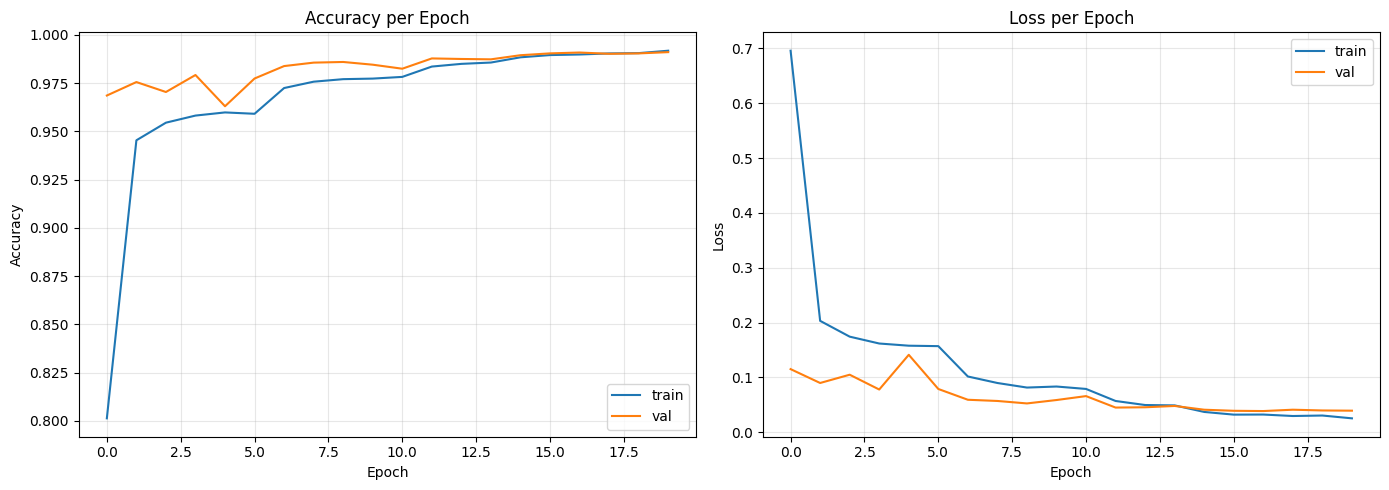

Best epoch (restored by EarlyStopping): epoch 20 — val_accuracy: 0.9910, val_loss: 0.0391


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_epoch = int(np.argmax(history.history['val_accuracy']))
print(f"Best epoch (restored by EarlyStopping): epoch {best_epoch + 1} — "
      f"val_accuracy: {history.history['val_accuracy'][best_epoch]:.4f}, "
      f"val_loss: {history.history['val_loss'][best_epoch]:.4f}")

## 11. Evaluation: Per-Class Performance

Angka akurasi keseluruhan bisa menyembunyikan performa buruk di kelas minoritas. Bagian ini mengecek precision/recall/F1 per huruf secara eksplisit, supaya klaim soal dampak `class_weight` terhadap huruf-huruf langka (`F`, `I`, dll.) bisa diverifikasi dari angka, bukan dugaan.

In [22]:
y_pred = np.argmax(model.predict(test_X), axis=1)
y_true = np.argmax(test_yOHE, axis=1)

target_names = [word_dict[i] for i in range(26)]
print(classification_report(y_true, y_pred, target_names=target_names, digits=3))

2328/2328 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
              precision    recall  f1-score   support

           A      0.992     0.993     0.992      2774
           B      0.992     0.992     0.992      1734
           C      0.992     0.994     0.993      4682
           D      0.916     0.990     0.951      2027
           E      0.995     0.993     0.994      2288
           F      0.983     0.991     0.987       233
           G      0.976     0.995     0.985      1152
           H      0.972     0.995     0.983      1444
           I      0.978     0.991     0.984       224
           J      0.974     0.990     0.982      1699
           K      0.990     0.993     0.992      1121
           L      0.994     0.991     0.992      2317
           M      0.995     0.988     0.992      2467
           N      0.993     0.987     0.990      3802
           O      0.998     0.981     0.990     11565
           P      0.998     0.995     0.996      3868
           Q      0.981     0.988     

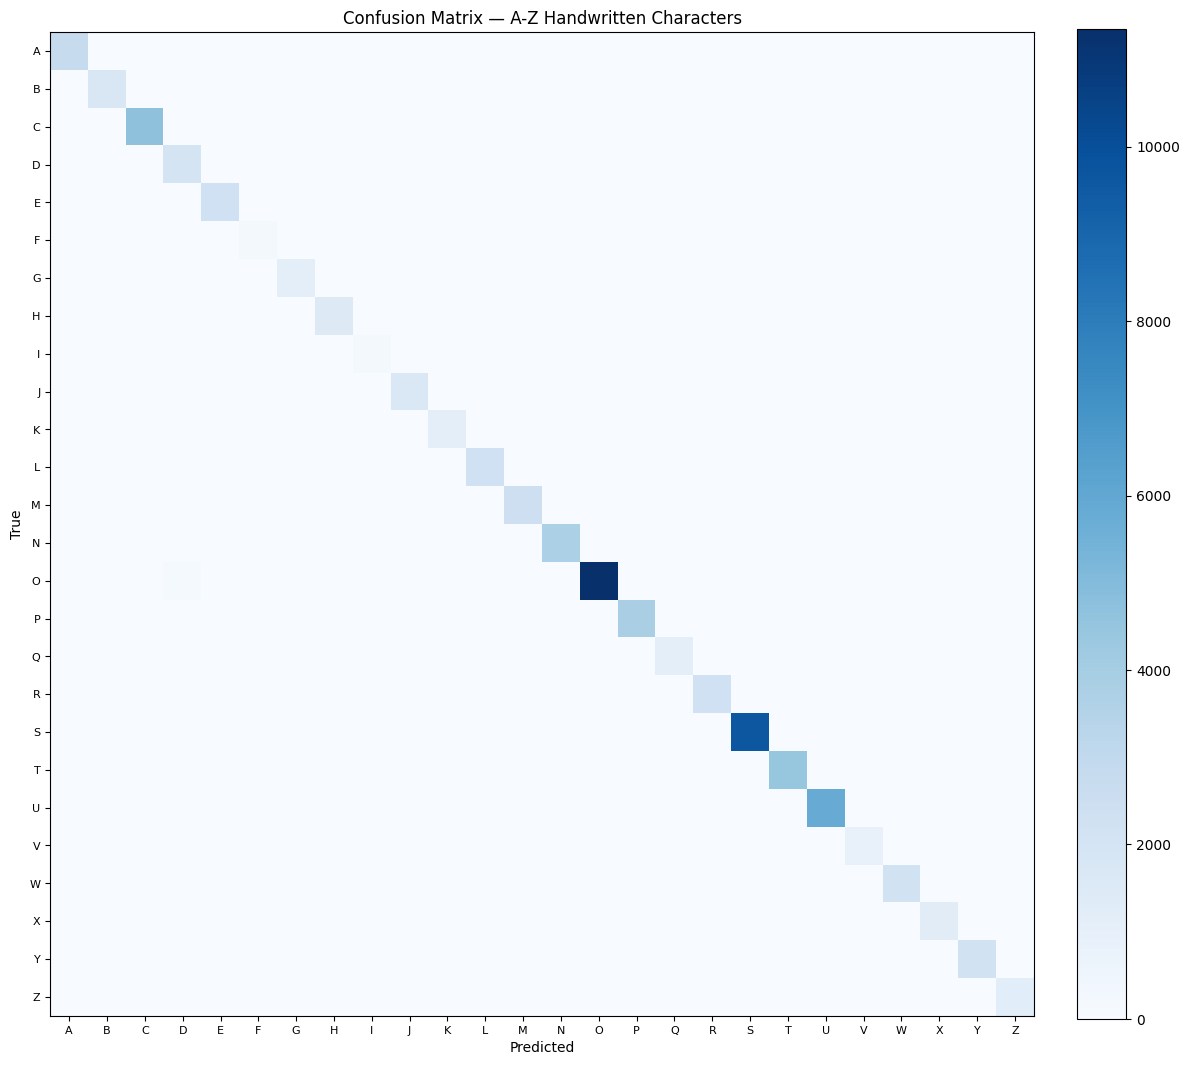

In [23]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(12, 12))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(26)); ax.set_xticklabels(target_names, fontsize=8)
ax.set_yticks(range(26)); ax.set_yticklabels(target_names, fontsize=8)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — A-Z Handwritten Characters')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 12. Qualitative Check

In [ ]:
fig, axes = plt.subplots(6,6, figsize=(10,11))
axes = axes.flatten()

for i,ax in enumerate(axes):
    img = np.reshape(test_X[i], (28,28))
    ax.imshow(img, cmap="Greys")

    pred = word_dict[y_pred[i]]
    ax.set_title("Prediction: "+pred)
    ax.grid()

---

*Hands-on material: rubythalib.ai*